# Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df = pd.read_csv("robot_dataset.csv")
df.head()

,x,y,z,j1,j2,j3
0,0.342804,0.320016,1.397473,0.750279,1.707771,0.772530
1,0.525125,1.784876,0.125520,1.284662,-0.450814,1.743365
2,2.132239,1.502163,0.805124,0.613740,0.411376,0.005295
3,1.627444,-0.398341,0.649622,-0.240046,0.159602,2.075303
4,2.146855,0.899873,1.173395,0.396913,0.674165,0.016547


In [2]:
df.shape


(50000, 6)

# Create Dataset Splits

In [3]:
X = df[["x", "y", "z"]].values
y = df[["j1", "j2", "j3"]].values

# 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Split temp into validation + test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train:", len(X_train))
print("Val:", len(X_val))
print("Test:", len(X_test))


Train: 35000
Val: 7500
Test: 7500


### Creating Tensors

In [4]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val = x_scaler.transform(X_val)
X_test = x_scaler.transform(X_test)

y_train = y_scaler.fit_transform(y_train)
y_val = y_scaler.transform(y_val)
y_test = y_scaler.transform(y_test)


In [5]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)


# Define Model

In [6]:
class IKNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(3, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.05),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.05),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 3),
        )

    def forward(self, x):
        return self.net(x)


In [7]:
model = IKNet()
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [8]:
train_losses = []
val_losses = []

best_val = float("inf")
patience = 20
counter = 0

for epoch in range(500):
    model.train()

    pred = model(X_train_t)
    train_loss = loss_fn(pred, y_train_t)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    model.eval()

    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = loss_fn(val_pred, y_val_t)

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    if epoch % 25 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"Train {train_loss.item():.6f} | "
            f"Val {val_loss.item():.6f}"
        )
    
    if val_loss < best_val:
        best_val = val_loss
        counter = 0

        torch.save(model.state_dict(), "best_robot_ik_model.pth")

    else:
        counter += 1

    if counter >= patience:
        print("Early stopping")
        break


Epoch   0 | Train 1.051313 | Val 1.000408
Epoch  25 | Train 0.051044 | Val 0.086775
Epoch  50 | Train 0.029538 | Val 0.035168
Epoch  75 | Train 0.023291 | Val 0.016155
Epoch 100 | Train 0.019745 | Val 0.010504
Epoch 125 | Train 0.017463 | Val 0.007938
Epoch 150 | Train 0.015796 | Val 0.006761
Epoch 175 | Train 0.014989 | Val 0.006048
Epoch 200 | Train 0.014001 | Val 0.005178
Epoch 225 | Train 0.013549 | Val 0.004618
Epoch 250 | Train 0.012425 | Val 0.004357
Epoch 275 | Train 0.011698 | Val 0.004396
Epoch 300 | Train 0.011167 | Val 0.003778
Epoch 325 | Train 0.010931 | Val 0.003765
Epoch 350 | Train 0.010334 | Val 0.003703
Epoch 375 | Train 0.010311 | Val 0.003741
Early stopping


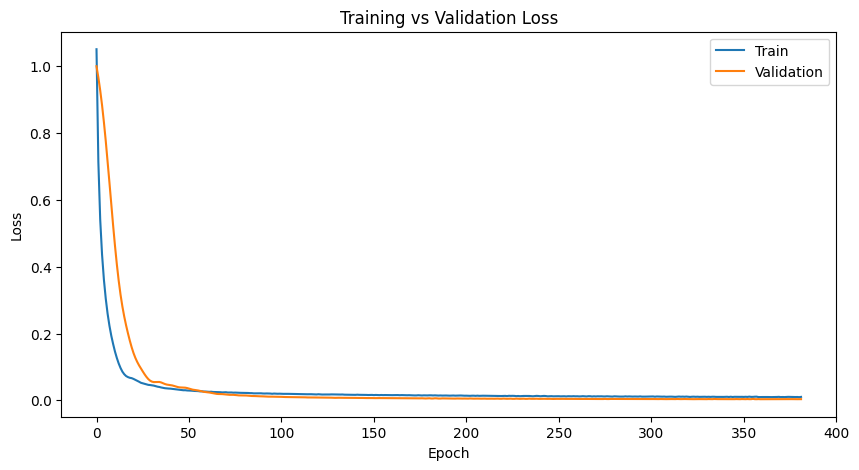

In [9]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()


In [10]:
model.eval()

with torch.no_grad():
    pred_test = model(X_test_t)
    test_loss = loss_fn(pred_test, y_test_t)

print("Test loss:", test_loss.item())


Test loss: 0.004927036352455616


In [11]:
import joblib

torch.save(model.state_dict(), "robot_ik_nn.pth")
joblib.dump(x_scaler, "x_scaler.pkl")
joblib.dump(y_scaler, "y_scaler.pkl")


['y_scaler.pkl']